In [1]:
###########  FLOWSql API client Python code  block to copy and paste ###########
import requests

class FLOWSql:
    def __init__(self, api_key: str,
                    url: str = "https://flows.phys.au.dk/api/sqlquery.php",
                    timeout: int = 30):
        """
        Initialize FLOWSql API client.

        Parameters
        ----------
        api_key : str
            API token for FLOWSql.
        url : str
            FLOWSql endpoint URL.
        timeout : int
            Request timeout in seconds.
        """
        self.api_key = api_key
        self.url = url
        self.timeout = timeout

        self.session = requests.Session()
        self.session.headers.update({
            "Authorization": f"Bearer {self.api_key}"
        })

    def query(self, sql: str, admin: bool = False) -> dict:
        """
        Execute an SQL query.

        Returns
        -------
        dict
            Select queries JSON format:
                {
                    "type": "select",
                    "columns": [...],
                    "rows": [...],
                    "count": int
                }

            Write queries (DELETE, UPDATE etc.) JSON format:
                {
                    "type": "write",
                    "affected_rows": int
                }
        """

        try:
            response = self.session.post(
                self.url,
                data={"query": sql, "admin": admin},
                timeout=self.timeout
            )
            response.raise_for_status()
        except requests.RequestException as e:
            raise FLOWSqlError(f"HTTP error: {e}") from e

        try:
            data = response.json()
        except ValueError:
            raise FLOWSqlError(f"Invalid JSON response: {response.text}")

        if not data.get("success"):
            raise FLOWSqlError(data.get("error", "Unknown API error"))

        if data["type"] == "select":
            return {
                "type": "select",
                "columns": data.get("columns", []),
                "rows": data.get("rows", []),
                "count": data.get("count", 0)
            }

        if data["type"] == "write":
            return {
                "type": "write",
                "affected_rows": data.get("affected_rows", 0)
            }

        raise FLOWSqlError(f"Unknown response format: {data}")


    def close(self):
        """Close HTTP session."""
        self.session.close()

class FLOWSqlError(Exception):
    """Raised when the SQL API returns an error."""
    pass

################# END FLOWSql API client Python code block  ###########


#### Set the FLOWS_API_KEY variable appropriately,
#### this hack may not work unless FLOWS_API_KEY is set in the bash environment ####
FLOWS_API_KEY=!bash -i -c 'echo $FLOWS_API_KEY'
FLOWS_API_KEY=FLOWS_API_KEY[-1]

In [2]:
fsql = FLOWSql(FLOWS_API_KEY)
result = fsql.query('''SELECT f.path, f.photfilter, t.target_name, s.sitename
FROM files f
JOIN targets t ON f.targetid = t.targetid
JOIN sites s ON f.site = s.siteid
WHERE f.datatype = 2
AND s.sitename = 'NOT'
AND t.target_status = 'target' ''')

filelist = [tuple(x.values()) for x in result['rows']]

#AND t.project = 'flows'

In [3]:
from itertools import groupby
import re

def get_highest_version_files(filelist):
    # Extract base name (without version) for grouping
    def base_key(entry):
        path = entry[0]
        # Remove version suffix to get base name
        base = re.sub(r'v\d+/photometry-.+', '', path)
        # Also normalize using filter and object name
        return (base, entry[1], entry[2])
    
    def version_num(entry):
        match = re.search(r'v(\d+)\.ecsv$', entry[0])
        return int(match.group(1)) if match else 0
    
    # Group by base path, keep only max version
    from collections import defaultdict
    groups = defaultdict(list)
    for entry in filelist:
        groups[base_key(entry)].append(entry)
    
    return [max(group, key=version_num) for group in groups.values()]

highest = get_highest_version_files(filelist)
len(highest)

1187

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from collections import defaultdict
import re
from astropy.stats import SigmaClip, mad_std
import copy

# --- Config ---
basedir='/nerdrage/calc/archive/photometry/'

color_bases = {
    'H_mag': ['J_mag', 'H_mag'],
    'J_mag': ['J_mag', 'H_mag'],
    'K_mag': ['H_mag', 'K_mag'],  # try with J - H
    'Y_mag': ['H_mag', 'K_mag'],  # Y need redefined
    'B_mag': ['B_mag', 'V_mag'],
    'V_mag': ['B_mag', 'V_mag'],
    'u_mag': ['u_mag', 'g_mag'],
    'g_mag': ['g_mag', 'r_mag'],
    'r_mag': ['g_mag', 'r_mag'],
    'i_mag': ['r_mag', 'i_mag'],
    'z_mag': ['i_mag', 'z_mag'],
}



filter_groups = defaultdict(list)
for filepath, filt, objname, sitename in highest:
    filt=filt[0:1]
    filter_groups[filt].append((filepath, objname))
filter_groups.keys()

dict_keys(['g', 'i', 'r', 'u', 'B', 'V', 'J', 'H', 'K', 'z', 'R'])

In [5]:
def color_fitter(X, Y, Xerr=None, Yerr=None, fitter='lin'):
    if fitter == 'linmix':
        from linmix.linmix import LinMix
        lm=LinMix(X, Y, Xerr, Yerr, parallelize=True, nchains=10)
        lm.run_mcmc(miniter=500, maxiter=5000, silent=True)

        slope, intercept = (np.median(lm.chain['beta']), np.median(lm.chain['alpha']))
        slope_error, intercept_error = (np.std(lm.chain['beta']), np.std(lm.chain['alpha']))
        return ([intercept,intercept_error], [slope,slope_error], np.poly1d([slope,intercept]), lm.chain)

    elif fitter == 'lin':
        if Xerr is not None:
            weights = 1.0 / (Yerr**2 + Xerr**2)
        else:
            weights = 1.0 / Yerr**2
        coeffs, cov = np.polyfit(X, Y, deg=1, w=weights, cov=True)
        slope, intercept = coeffs
        slope_error, intercept_error = np.sqrt(np.diag(cov))
        return ([intercept,intercept_error], [slope,slope_error], np.poly1d(coeffs), None)
    else:
        raise ValueError(f"Unknown fitter type: {fitter}")
  
        

No of files to read for filter g 93
Niter 8, -> Color term: [np.float64(0.10388918094563282), np.float64(0.0024756469486100353)]                         
  Converged after 8 iterations

Filter g:
  x-axis : g_mag - r_mag
  y-axis : instmag - g_mag
  color_term = 0.104305 ± 0.002480
  intercept  = -0.000289 ± 0.001842
  N stars    = 1670
  N clipped  = 146


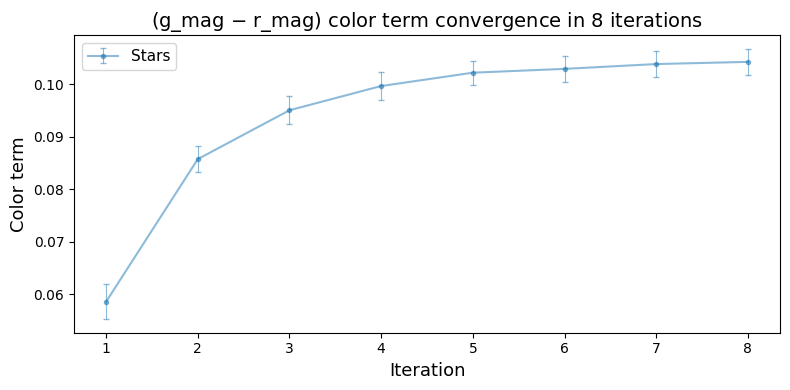

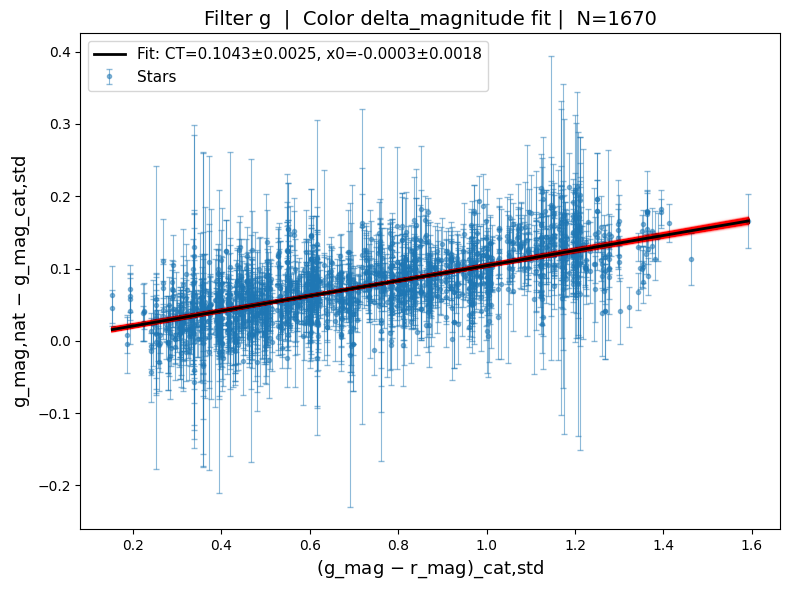

No of files to read for filter i 114
Niter 4, -> Color term: [np.float64(-0.06971722142587275), np.float64(0.0023649534456810437)]                         
  Converged after 4 iterations

Filter i:
  x-axis : r_mag - i_mag
  y-axis : instmag - i_mag
  color_term = -0.069938 ± 0.002253
  intercept  = 0.002353 ± 0.001176
  N stars    = 2919
  N clipped  = 424


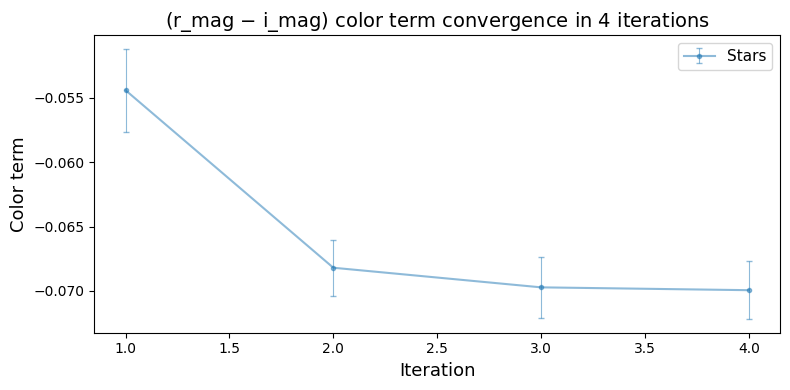

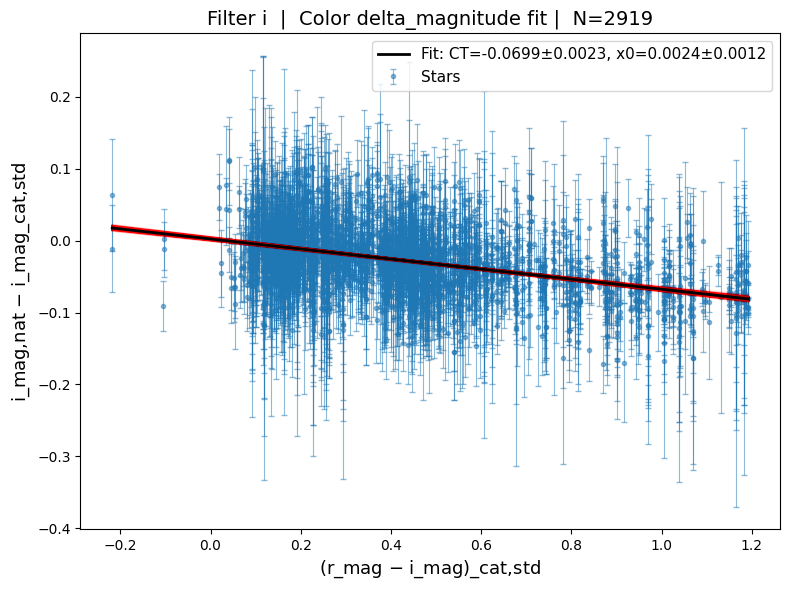

No of files to read for filter r 111
Niter 2, -> Color term: [np.float64(0.0012239250930533732), np.float64(0.0018699050119934347)]                         
  Converged after 2 iterations

Filter r:
  x-axis : g_mag - r_mag
  y-axis : instmag - r_mag
  color_term = 0.001426 ± 0.001863
  intercept  = 0.000909 ± 0.001584
  N stars    = 2650
  N clipped  = 243


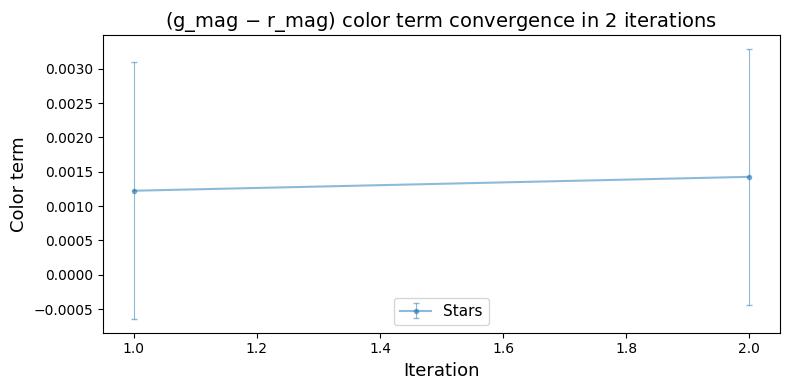

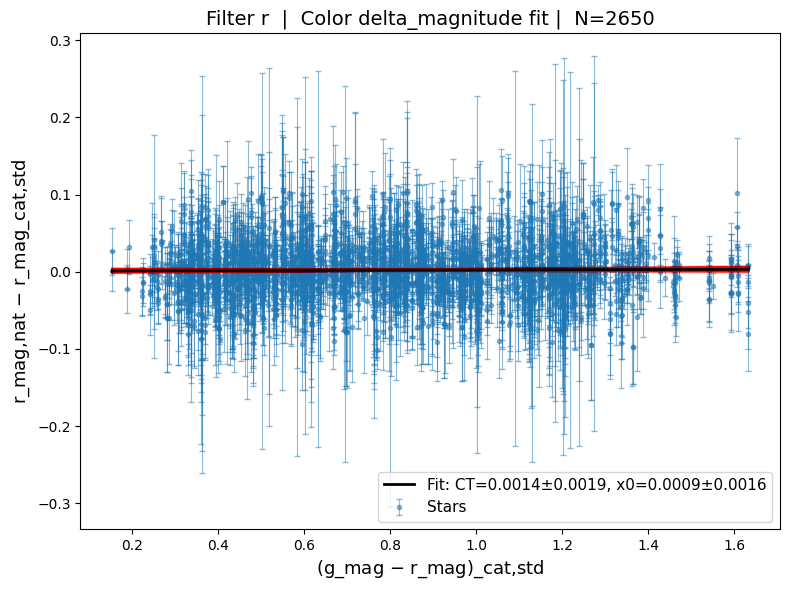

No of files to read for filter u 23


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/tljh/user/envs/py310/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



  Converged after 8 iterations

Filter u:
  x-axis : u_mag - g_mag
  y-axis : instmag - u_mag
  color_term = -0.050425 ± 0.011600
  intercept  = 0.001313 ± 0.018291
  N stars    = 109
  N clipped  = 8


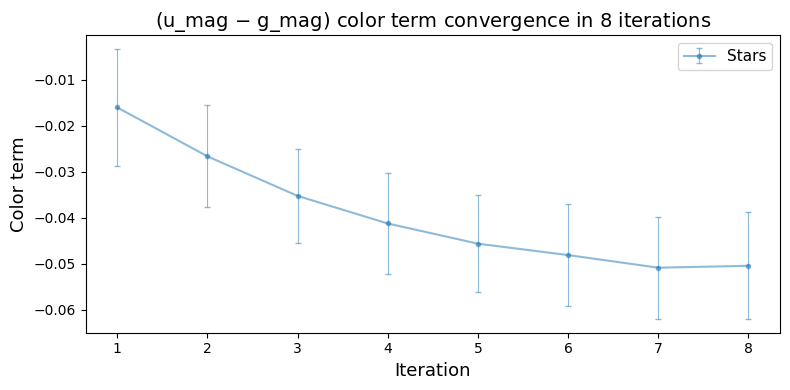

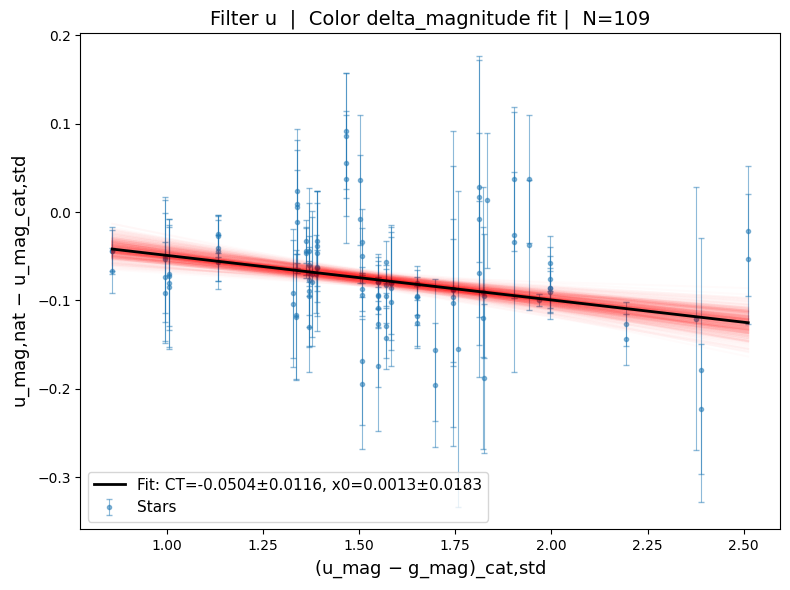

No of files to read for filter B 109
Niter 9, -> Color term: [np.float64(-0.05864048909888206), np.float64(0.009849819921630896)]                          
  Converged after 9 iterations

Filter B:
  x-axis : B_mag - V_mag
  y-axis : instmag - B_mag
  color_term = -0.058794 ± 0.006962
  intercept  = 0.001471 ± 0.005442
  N stars    = 907
  N clipped  = 152


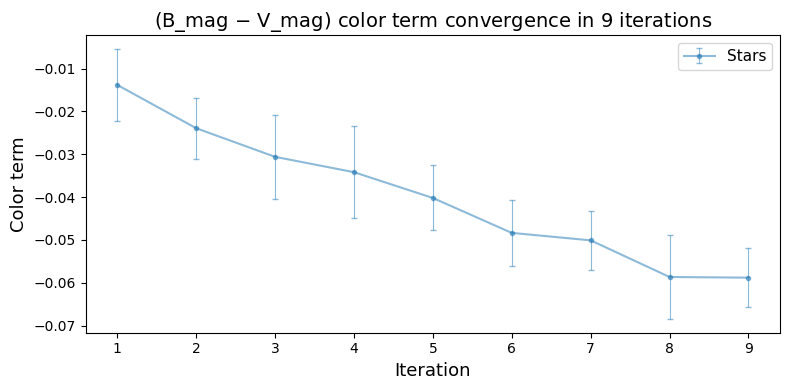

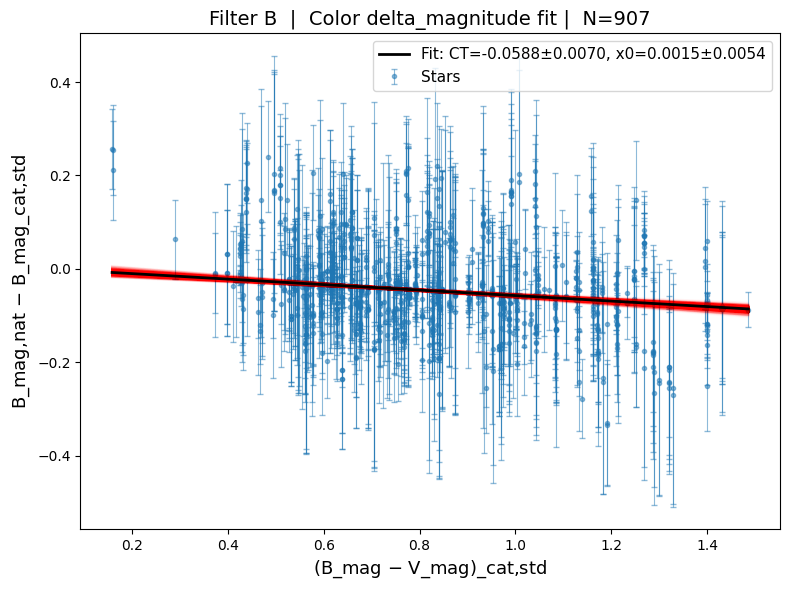

No of files to read for filter V 102
Niter 17, -> Color term: [np.float64(0.06200915385526282), np.float64(0.007025541580882506)]                           
  Converged after 17 iterations

Filter V:
  x-axis : B_mag - V_mag
  y-axis : instmag - V_mag
  color_term = 0.061596 ± 0.007012
  intercept  = 0.003136 ± 0.005579
  N stars    = 782
  N clipped  = 182


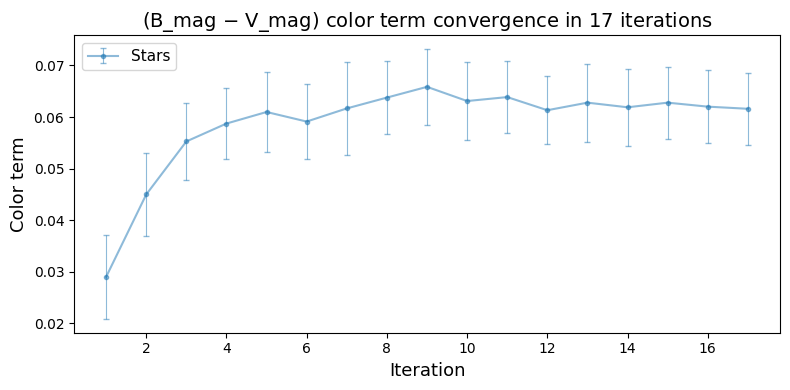

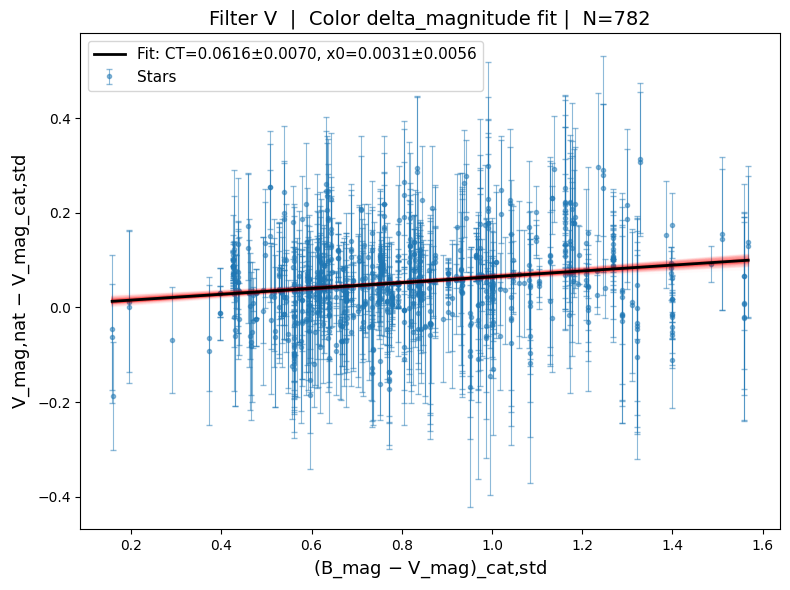

No of files to read for filter J 293
Niter 4, -> Color term: [np.float64(-0.18693585715271882), np.float64(0.006066785027709092)]                          
  Converged after 4 iterations

Filter J:
  x-axis : J_mag - H_mag
  y-axis : instmag - J_mag
  color_term = -0.186483 ± 0.006171
  intercept  = 0.002985 ± 0.003411
  N stars    = 6171
  N clipped  = 863


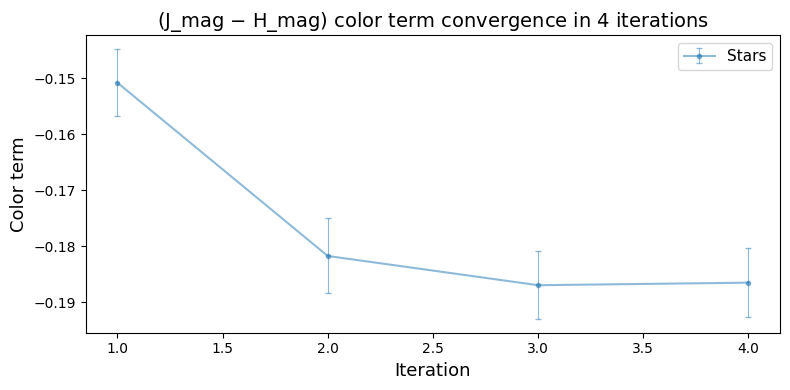

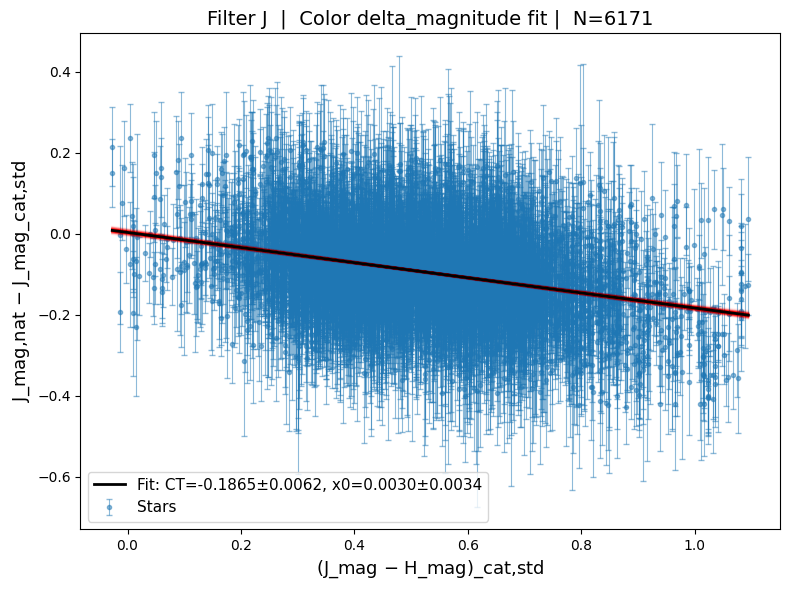

No of files to read for filter H 289
Niter 7, -> Color term: [np.float64(0.31498298588949725), np.float64(0.00722420202566604)]                          
  Converged after 7 iterations

Filter H:
  x-axis : J_mag - H_mag
  y-axis : instmag - H_mag
  color_term = 0.315094 ± 0.009458
  intercept  = 0.002323 ± 0.004952
  N stars    = 6174
  N clipped  = 925


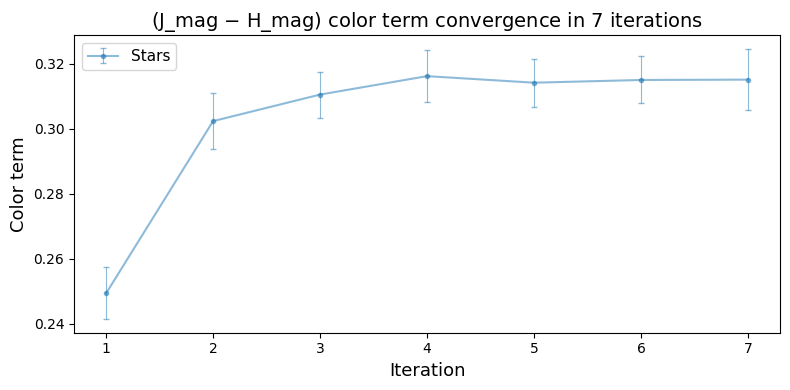

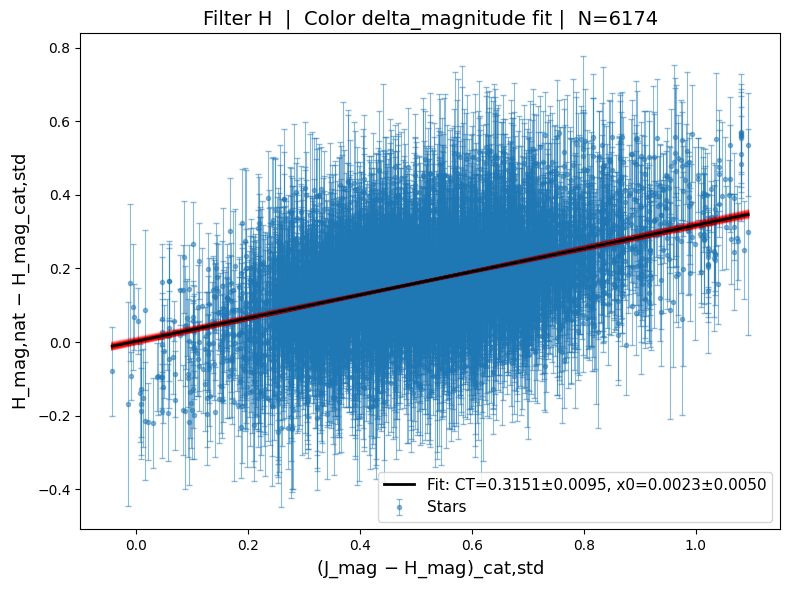

No of files to read for filter K 37
Niter 7, -> Color term: [np.float64(0.47723836560259714), np.float64(0.027225699553204846)]                         
  Converged after 7 iterations

Filter K:
  x-axis : H_mag - K_mag
  y-axis : instmag - K_mag
  color_term = 0.477098 ± 0.026528
  intercept  = 0.009601 ± 0.006305
  N stars    = 1083
  N clipped  = 165


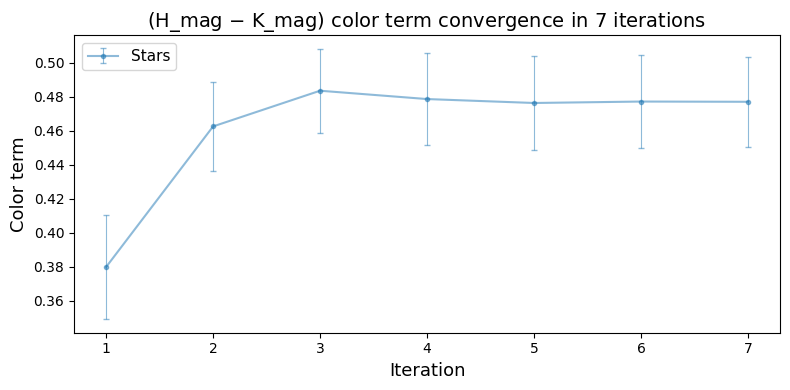

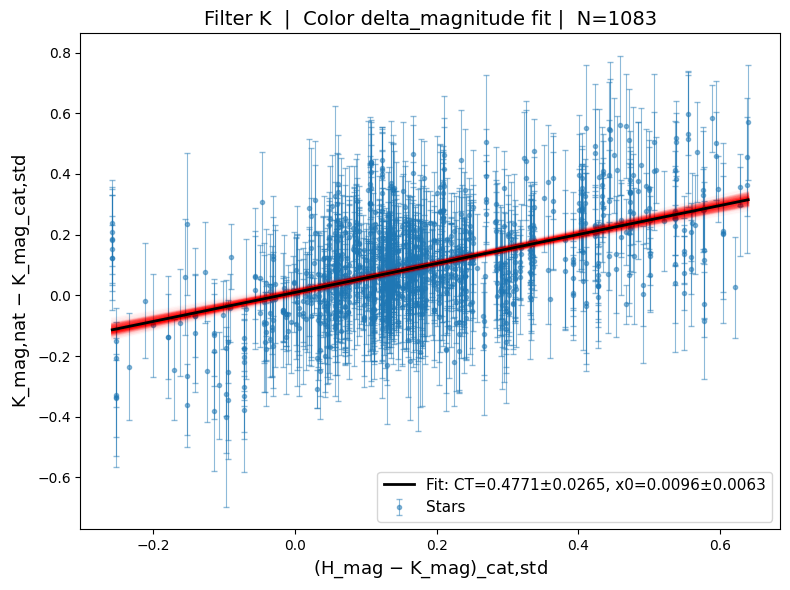

No of files to read for filter z 15
Niter 5, -> Color term: [np.float64(-0.12025401095631424), np.float64(0.008318474575940482)]                         
  Converged after 5 iterations

Filter z:
  x-axis : i_mag - z_mag
  y-axis : instmag - z_mag
  color_term = -0.119840 ± 0.007836
  intercept  = 0.002770 ± 0.001768
  N stars    = 578
  N clipped  = 72


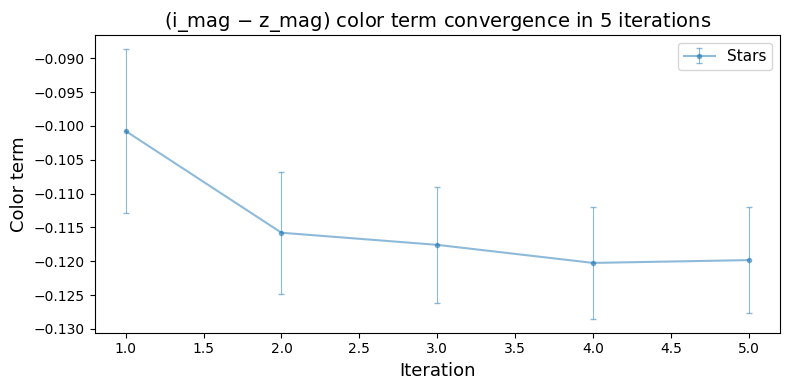

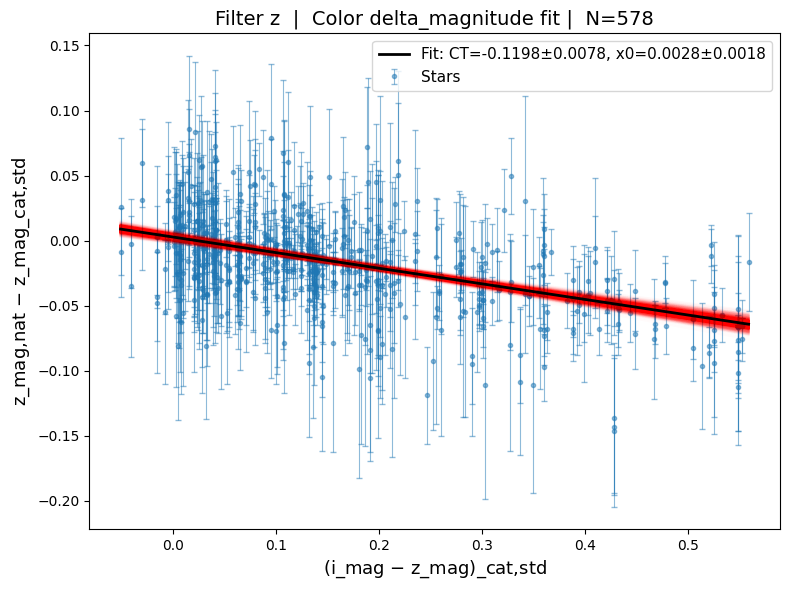

No of files to read for filter R 1
Skipping filter R: no color_bases entry for R_mag


In [6]:
for filt in list(filter_groups.keys()):
    file_entries=filter_groups[filt] 
    print("No of files to read for filter",filt,len(file_entries))
    mag_col = f'{filt}_mag'

    if mag_col not in color_bases:
        print(f"Skipping filter {filt}: no color_bases entry for {mag_col}")
        continue

    color_col0, color_col1 = color_bases[mag_col]  # e.g. ['J_mag', 'H_mag']

    all_color, all_Dmag, all_Dmag_err = [], [], []

    for filepath, objname in file_entries:
        try:
            t = Table.read(basedir + filepath, format='ascii.ecsv')
            t = t[t['starid']>0]  # skip SN mag

            # Required columns
            needed = ['flux_psf', 'flux_psf_error', 'mag', 'mag_error',
                      mag_col, color_col0, color_col1]
            if not all(col in t.colnames for col in needed):
                missing = [c for c in needed if c not in t.colnames]
                print(f"  Skipping {filepath}: missing columns {missing}")
                continue

            flux     = np.array(t['flux_psf'].data,        dtype=float)
            flux_err = np.array(t['flux_psf_error'].data,  dtype=float)
            mag      = np.array(t['mag'].data,             dtype=float)
            ref_mag  = np.array(t[mag_col].data,           dtype=float)
            col0     = np.array(t[color_col0].data,        dtype=float)
            col1     = np.array(t[color_col1].data,        dtype=float)

            # Mask out bad values
            valid = (flux > 0) & np.isfinite(flux) & np.isfinite(ref_mag) \
                  & np.isfinite(col0) & np.isfinite(col1) & (ref_mag !=0) & (col0 !=0) & (col1 !=0) & (col0 != col1)
            flux     = flux[valid];     flux_err = flux_err[valid]
            mag      = mag[valid];      ref_mag  = ref_mag[valid]
            col0     = col0[valid];     col1     = col1[valid]

            # Instrumental magnitude and error
            instmag       = -2.5 * np.log10(flux) + 24
            instmag_error = 2.5 * flux_err / flux / np.log(10)

            # Axes
            y = mag - ref_mag                  # instrumental - catalog mag
            x = col0 - col1                        # e.g. J_mag - H_mag

            if np.any(x==0):
                print(f"  x==0 for {basedir+filepath}")
                

            all_color.append(x)
            all_Dmag.append(y)
            all_Dmag_err.append(instmag_error)   # This is to ensure we use the photometry error only

        except Exception as e:
            print(f"  Error reading {filepath}: {e}")
            continue

    if not all_Dmag:
        print(f"No valid data for filter {filt}, skipping plot.")
        continue

    color_term=[[0, 0]]

    while True:
        if len(color_term) > 30:
            print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}                         ")
            if len(color_term) > 40:
                print("Warning!! Didn't converge")
                break
        else:
            print(f"Niter {len(color_term)}, -> Color term: {color_term[-1]}                         ",end='\r')
        CP_all_color=copy.deepcopy(all_color)
        CP_all_Dmag=copy.deepcopy(all_Dmag)
        CP_all_Dmag_err=copy.deepcopy(all_Dmag_err)

        ### Here we calculate ZP with CT correction applied for each data set in the list
        for i in range(len(CP_all_color)):
            tmp = CP_all_Dmag[i] - color_term[-1][0] * CP_all_color[i]
            sigclip = SigmaClip(sigma=3, maxiters=5)
            mask = ~sigclip(tmp).mask
            CP_all_Dmag[i] = CP_all_Dmag[i] - np.median(tmp[mask])
            CP_all_Dmag_err[i] = np.sqrt( CP_all_Dmag_err[i]**2 + (np.std(tmp[mask]))**2 )      # sigma= MAD*1.4826 
            #CP_all_color[i] = CP_all_color[i][mask]


        # Concatenate across all files for this filter
        X    = np.concatenate(CP_all_color)
        Y    = np.concatenate(CP_all_Dmag)
        Yerr = np.concatenate(CP_all_Dmag_err)

        # --- Linear fit (weighted by 1/err^2) ---
        # Mask out any non-finite values or zero/negative errors
        fit_mask = (np.isfinite(X) & np.isfinite(Y) & np.isfinite(Yerr) & (Yerr > 0) & (Yerr <.3))


        if fit_mask.sum() < 2:
            print(f"  Not enough valid points to fit for filter {filt}  ")
            break

        Xf, Yf, Yef = X[fit_mask], Y[fit_mask], Yerr[fit_mask]
        
        if len(Xf) < 3:
            print(f"  Not enough points for covariance estimate   ")
            break


        from astropy.stats import SigmaClip
        fit_mask = ~SigmaClip(sigma=3, maxiters=5)(Xf).mask & ~SigmaClip(sigma=3, maxiters=5)(Yf).mask
        #Xf, Yf, Yef = Xf[fit_mask], Yf[fit_mask], Yef[fit_mask]
        #print(f"Sigma clipped along X, discarded {(~fit_mask).sum()} points")

        
        sigclip = SigmaClip(sigma=3, maxiters=3)
        chain = None
        for i in range(5):
            #weights = 1.0 / Yef[fit_mask]**2
            #coeffs, cov = np.polyfit(Xf[fit_mask], Yf[fit_mask], deg=1, w=weights, cov=True)
            #slope, intercept = coeffs
            #slope_error, intercept_error = np.sqrt(np.diag(cov))
            #fit_line = np.poly1d(coeffs)
            (intercept, intercept_error), (slope, slope_error), fit_line, chain = color_fitter(Xf[fit_mask], Yf[fit_mask], Xerr=None, Yerr=Yef[fit_mask], fitter='linmix')
            
            tmp=Yf[fit_mask]-fit_line(Xf[fit_mask])
            fit_mask[fit_mask] = fit_mask[fit_mask] & ~sigclip(tmp).mask
        Xf, Yf, Yef = Xf[fit_mask], Yf[fit_mask], Yef[fit_mask]

        #if np.abs(color_term[-1][0] -slope) < np.abs(slope)/1000:  # This is 4 dec sig. fig. point accurate?
        if np.abs(color_term[-1][0] -slope) < 0.0005:  # This is 3 decimal point accurate?
            color_term.append([slope,slope_error])
            print(f"\n  Converged after {len(color_term)-1} iterations")
            break
        color_term.append([slope,slope_error])
        
    #print("Final color term: ", color_term)

    print(f"\nFilter {filt}:")
    print(f"  x-axis : {color_col0} - {color_col1}")
    print(f"  y-axis : instmag - {mag_col}")
    print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    print(f"  N stars    = {len(Xf)}")
    print(f"  N clipped  = {len(np.concatenate(all_color)) - len(Xf)}")



    #chain=None
    #(intercept, intercept_error), (slope, slope_error), fit_line, chain = color_fitter(Xf, Yf, Xerr=None, Yerr=Yef, fitter='linmix')
    #color_term.append([slope,slope_error])
    #
    #print(f"\nLinMax Result:")
    #print(f"\nFilter {filt}:")
    #print(f"  x-axis : {color_col0} - {color_col1}")
    #print(f"  y-axis : instmag - {mag_col}")
    #print(f"  color_term = {slope:.6f} ± {slope_error:.6f}")
    #print(f"  intercept  = {intercept:.6f} ± {intercept_error:.6f}")
    #print(f"  N stars    = {len(Xf)}")
    #print(f"  N clipped  = {len(np.concatenate(all_color)) - len(Xf)}")



    x_fit = np.linspace(Xf.min(), Xf.max(), 300)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(np.arange(1,len(color_term)), np.array(color_term)[1:,0], yerr=np.array(color_term)[1:,1], fmt='o-', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars')

    ax.set_xlabel('Iteration', fontsize=13)
    ax.set_ylabel('Color term', fontsize=13)
    ax.set_title(f'({color_col0} $-$ {color_col1}) color term convergence in {len(color_term)-1} iterations', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(Xf, Yf, yerr=Yef, fmt='o', ms=3, alpha=0.5,
                elinewidth=0.8, capsize=2, label='Stars', zorder=1)
    ax.plot(x_fit, fit_line(x_fit), 'k-', lw=2,
            label=f'Fit: CT={slope:.4f}±{slope_error:.4f}, x0={intercept:.4f}±{intercept_error:.4f}', zorder=3)

    if chain is not None:
        for i in range(0, len(chain), 20):
            ys = chain[i]['alpha'] + x_fit * chain[i]['beta']
            ax.plot(x_fit, ys, color='r', alpha=0.015, zorder=2)

    ax.set_xlabel(f'({color_col0} $-$ {color_col1})_cat,std', fontsize=13)
    ax.set_ylabel(f'{mag_col},nat $-$ {mag_col}_cat,std', fontsize=13)
    ax.set_title(f'Filter {filt}  |  Color delta_magnitude fit |  N={len(Xf)}', fontsize=14)
    ax.legend(fontsize=11)
    #ax.invert_yaxis() 
    plt.tight_layout()
    plt.show()


---
### All trash below

In [90]:
np.arange(1,5)

array([1, 2, 3, 4])

In [42]:
(~fit_mask2).sum()

np.int64(-4380)

In [24]:
fit_mask

array([ True,  True,  True, ...,  True,  True,  True], shape=(4777,))